In [4]:
import pandas as pd
import numpy as np
data = {
    "value": [120, 135, 128, 150, 160, 155, 170, 180, 175, 190, 200, 210, 195, 205, 215]
}
df = pd.DataFrame(data)
df.to_csv("series.csv", index=False)
df

,value
0,120
1,135
2,128
3,150
4,160
5,155
6,170
7,180
8,175
9,190


In [5]:
df = pd.read_csv("series.csv")
arr = df["value"].to_numpy()
previous_values = arr[:-1]
current_values = arr[1:]
print("Length of matching part:", len(current_values))
print("Previous values:", previous_values)
print("Current values:", current_values)

Length of matching part: 14
Previous values: [120 135 128 150 160 155 170 180 175 190 200 210 195 205]
Current values: [135 128 150 160 155 170 180 175 190 200 210 195 205 215]


In [6]:
values = df["value"].to_numpy()
window = 3
cumsum = np.cumsum(values)
roll3_numpy = []
for i in range(len(values)):
    if i < window - 1:
        roll3_numpy.append(np.nan)
    else:
        if i == window - 1:
            total = cumsum[i]
        else:
            total = cumsum[i] - cumsum[i - window]
        roll3_numpy.append(total / window)
print("Rolling mean window 3:")
print(roll3_numpy)

Rolling mean window 3:
[nan, nan, np.float64(127.66666666666667), np.float64(137.66666666666666), np.float64(146.0), np.float64(155.0), np.float64(161.66666666666666), np.float64(168.33333333333334), np.float64(175.0), np.float64(181.66666666666666), np.float64(188.33333333333334), np.float64(200.0), np.float64(201.66666666666666), np.float64(203.33333333333334), np.float64(205.0)]


In [7]:
roll3_pandas = df["value"].rolling(3).mean()
compare = pd.DataFrame({
    "value": df["value"],
    "roll3_numpy": roll3_numpy,
    "roll3_pandas": roll3_pandas
})
compare

,value,roll3_numpy,roll3_pandas
0,120,NaN,NaN
1,135,NaN,NaN
2,128,127.666667,127.666667
3,150,137.666667,137.666667
4,160,146.000000,146.000000
5,155,155.000000,155.000000
6,170,161.666667,161.666667
7,180,168.333333,168.333333
8,175,175.000000,175.000000
9,190,181.666667,181.666667


In [8]:
df["lag1"] = df["value"].shift(1)
df["roll3"] = df["value"].rolling(3).mean()
df

,value,lag1,roll3
0,120,NaN,NaN
1,135,120.0,NaN
2,128,135.0,127.666667
3,150,128.0,137.666667
4,160,150.0,146.000000
5,155,160.0,155.000000
6,170,155.0,161.666667
7,180,170.0,168.333333
8,175,180.0,175.000000
9,190,175.0,181.666667


In [9]:
df.to_csv("features.csv", index=False)
print("features.csv saved successfully")

features.csv saved successfully


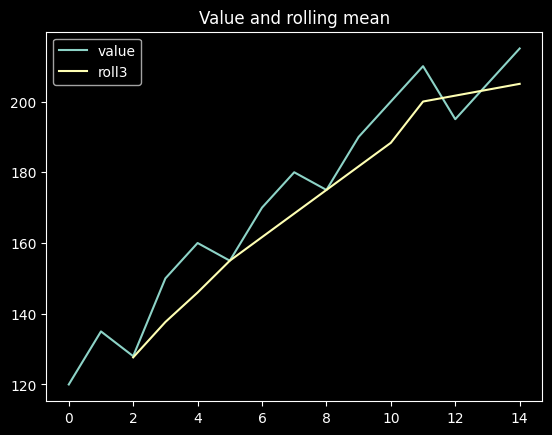

In [10]:
import matplotlib.pyplot as plt
plt.plot(df["value"], label="value")
plt.plot(df["roll3"], label="roll3")
plt.legend()
plt.title("Value and rolling mean")
plt.savefig("line_value_roll3.png")
plt.show()